In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, HybridAEVAE, AEVAE
import numpy as np
import torch
import skdim
import os
from scipy.stats import entropy
from sklearn.cluster import MiniBatchKMeans
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 100000 # 20k
num_epochs = 50
steps_per_epoch = 200 # 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = gym.make('Pendulum-v1', render_mode='rgb_array')
env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
# env = DomainRandomization(env, {"g": (5.0, 20.0)})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [2]:
obs, _ = env.reset()

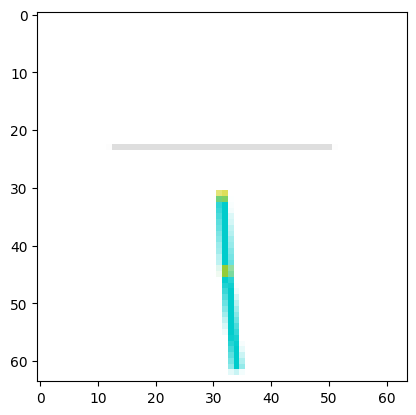

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "hybrid_testing.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(512)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

2000
4000
6000
8000
10000


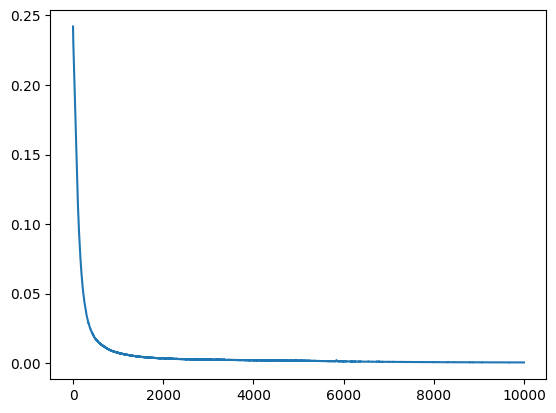

In [7]:
plt.plot(losses)


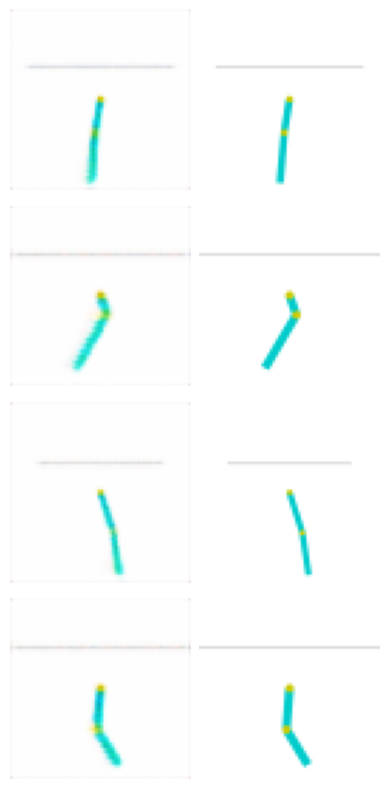

In [8]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [9]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 6.072762864305393 +- 0.08665345585882887
Image ID: 9.739271513075725 +- 0.1515944382288943


Epoch  10  |  loss: 0.002573  |  temp: 0.655  |  phase: warmup

Temperature: 0.6551
 Dim    Gate         Type  Centroids
------------------------------------------------------------
   0   0.805   continuous  [-2.22  -1.42  -0.85  -0.28  +0.29  +0.85  +1.42  +2.27]
   1   0.673   continuous  [-2.40  -1.34  -0.93  -0.24  +0.24  +0.96  +1.37  +2.35]
   2   0.739   continuous  [-2.11  -1.34  -0.82  -0.30  +0.24  +0.78  +1.31  +2.30]
   3   0.797   continuous  [-2.36  -1.44  -0.85  -0.28  +0.29  +0.85  +1.42  +2.36]
   4   0.787   continuous  [-2.31  -1.42  -0.85  -0.28  +0.28  +0.85  +1.43  +2.25]
   5   0.723   continuous  [-2.32  -1.28  -0.76  -0.19  +0.26  +0.84  +1.34  +2.14]

Epoch  20  |  loss: 0.002425  |  temp: 0.409  |  phase: discretize

Temperature: 0.4095
 Dim    Gate         Type  Centroids
------------------------------------------------------------
   0   0.590   continuous  [-2.58  -1.42  -0.84  -0.28  +0.28  +0.85  +1.41  +2.63]
   1   0.512   continuous  [-2.46  -1.38  -

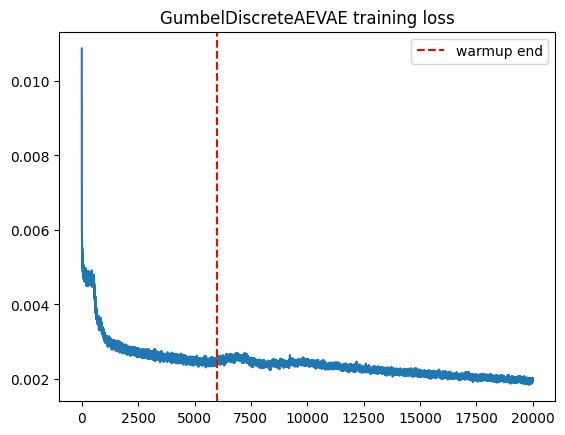


Temperature: 0.1000
 Dim    Gate         Type  Centroids
------------------------------------------------------------
   0   0.268     discrete  [-2.50  -1.40  -0.83  -0.28  +0.28  +0.84  +1.39  +2.50]
   1   0.289     discrete  [-2.27  -1.42  -0.93  -0.21  +0.20  +1.19  +1.34  +2.28]
   2   0.447     discrete  [-2.09  -1.13  -0.75  +0.01  +0.03  +0.73  +1.19  +2.31]
   3   0.259     discrete  [-2.67  -1.41  -0.84  -0.28  +0.28  +0.83  +1.39  +2.48]
   4   0.298     discrete  [-2.49  -1.39  -0.83  -0.28  +0.28  +0.84  +1.39  +1.98]
   5   0.382     discrete  [-2.31  -1.20  -0.68  -0.06  +0.05  +0.75  +1.15  +2.11]



In [10]:
# ── Cell: Train GumbelDiscreteAEVAE (with warmup) ──
from gumbel_bottleneck import GumbelDiscreteAEVAE

intrinsic_dim = round(np.mean(latent_ID))

gumbel_model = GumbelDiscreteAEVAE(
    encoder, decoder, latent_dim, intrinsic_dim,
    num_categories=8,
    penalty_coef=1e-4,
    entropy_weight=0.01,
    gate_weight=0.001,        # 10x lower than before
    init_temperature=1.0,
).cuda()

gumbel_opt = torch.optim.AdamW(gumbel_model.parameters(), 3e-4)
gumbel_scheduler = torch.optim.lr_scheduler.ExponentialLR(gumbel_opt, gamma=0.97)

warmup_epochs = 15
post_entropy_weight = 0.01
post_gate_weight = 0.001

losses = []
for epoch in range(1, num_epochs + 1):
    temp = gumbel_model.anneal_temperature(epoch - 1, num_epochs,
                                           temp_min=0.1, temp_max=1.0)

    # Warmup: pure reconstruction, no discretization pressure
    if epoch <= warmup_epochs:
        gumbel_model.gate_weight = 0.0
        gumbel_model.entropy_weight = 0.0
    else:
        # Ramp penalties in linearly over 10 epochs after warmup
        ramp = min((epoch - warmup_epochs) / 10.0, 1.0)
        gumbel_model.gate_weight = post_gate_weight * ramp
        gumbel_model.entropy_weight = post_entropy_weight * ramp

    for _ in range(2 * steps_per_epoch):
        samples = buffer.sample(512)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = gumbel_model.reconstruction_loss(obs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gumbel_model.parameters(), 1.0)
        gumbel_opt.step()
        gumbel_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())

    gumbel_scheduler.step()

    if epoch % 10 == 0:
        avg_loss = np.mean(losses[-2*steps_per_epoch:])
        phase = "warmup" if epoch <= warmup_epochs else "discretize"
        print(f"Epoch {epoch:>3d}  |  loss: {avg_loss:.6f}  |  temp: {temp:.3f}  |  phase: {phase}")
        gumbel_model.diagnostics()

plt.plot(losses)
plt.axvline(x=warmup_epochs * 2 * steps_per_epoch, color='r', linestyle='--', label='warmup end')
plt.title("GumbelDiscreteAEVAE training loss")
plt.legend()
plt.show()

gumbel_model.eval()
gumbel_model.diagnostics()

Reconstruction MSE (Gumbel, deterministic): 0.001189


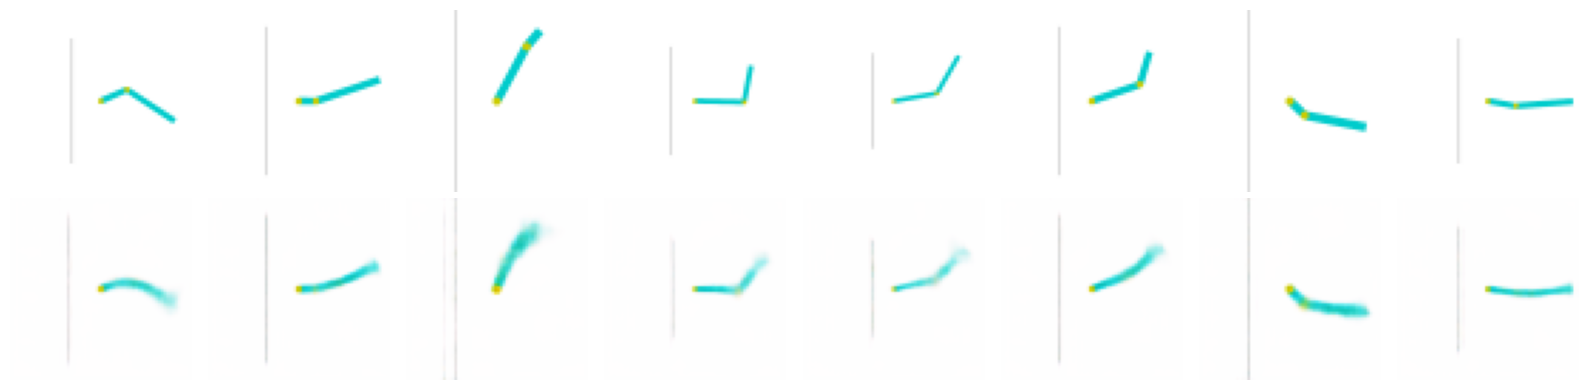


Category usage (top categories per dim):
 Dim    Gate  Effective K  Top categories
-----------------------------------------------------------------
   0   0.268          1.6  c7=84%, c0=16%
   1   0.289          2.3  c7=75%, c0=15%, c5=4%, c3=3%
   2   0.447          2.4  c7=55%, c0=41%, c1=1%, c6=1%
   3   0.259          1.6  c7=83%, c0=17%
   4   0.298          1.7  c0=78%, c7=22%
   5   0.382          2.5  c0=56%, c7=38%, c1=2%, c6=2%



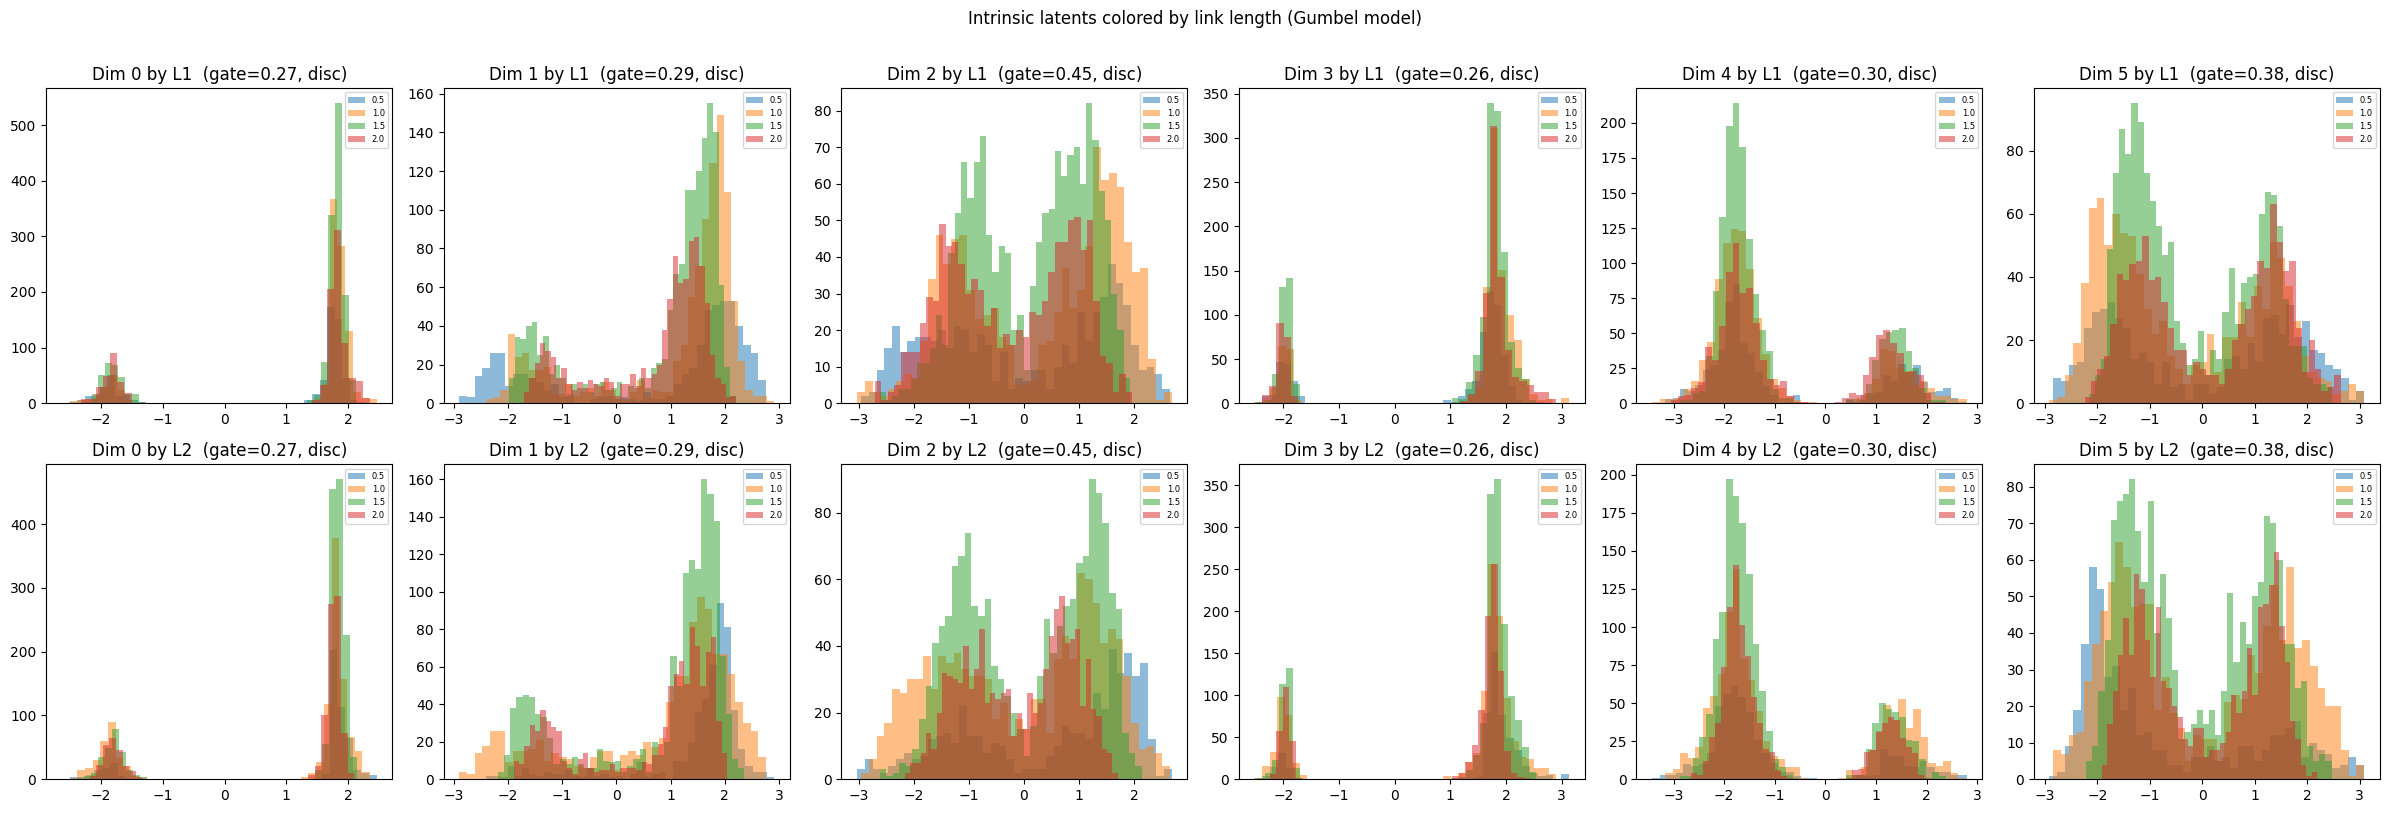

In [11]:
# ── Cell: Post-training analysis ──
# Run after training the GumbelDiscreteAEVAE

gumbel_model.eval()

# ── 1. Reconstruction quality ──
samples = buffer.sample(2048)
obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()

with torch.no_grad():
    Z = gumbel_model.double_encode_deterministic(obs)
    recon = gumbel_model.double_decode(Z)

mse = F.mse_loss(recon, obs).item()
print(f"Reconstruction MSE (Gumbel, deterministic): {mse:.6f}")

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
obs_np = to_numpy(obs.permute(0, 2, 3, 1))
recon_np = to_numpy(recon.permute(0, 2, 3, 1))
for j in range(n_show):
    axes[0, j].imshow(obs_np[j, :, :, :3])
    axes[1, j].imshow(recon_np[j, :, :, :3])
    axes[0, j].axis('off')
    axes[1, j].axis('off')
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Gumbel recon")
plt.tight_layout()
plt.show()

# ── 2. Category usage on held-out data ──
def sample_batch():
    s = buffer.sample(512)
    return (torch.tensor(s[0]).float().transpose(-3, -1) / 255).cuda()

gumbel_model.category_usage(sample_batch, n_batches=20)

# ── 3. Colored histograms by link length ──
# Collect fresh data with link-length labels
obs_eval, _ = env.reset()
link_labels = []
obs_list = []

for _ in range(4096):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    obs_list.append(obs_eval)
    link_labels.append([env.unwrapped.LINK_LENGTH_1, env.unwrapped.LINK_LENGTH_2])
    if terminated or truncated:
        obs_eval, _ = env.reset()
    else:
        obs_eval = next_obs

obs_tensor = (torch.tensor(np.array(obs_list)).float().transpose(-3, -1) / 255).cuda()
link_labels = np.array(link_labels)

with torch.no_grad():
    Z_eval = to_numpy(gumbel_model.double_encode_deterministic(obs_tensor))

gate = gumbel_model.get_gate().detach().cpu().numpy()

fig, axes = plt.subplots(2, intrinsic_dim, figsize=(4 * intrinsic_dim, 8))

for i in range(intrinsic_dim):
    g = gate[i]
    for j, (link_vals, labels, name) in enumerate(zip(
        [[0.5, 1.0, 1.5, 2.0]] * 2,
        [link_labels[:, 0], link_labels[:, 1]],
        ["L1", "L2"]
    )):
        for val in link_vals:
            mask = labels == val
            axes[j, i].hist(Z_eval[mask, i], bins=40, alpha=0.5, label=f"{val}")
        kind = "disc" if g < 0.5 else "cont"
        axes[j, i].set_title(f"Dim {i} by {name}  (gate={g:.2f}, {kind})")
        axes[j, i].legend(fontsize=6)

plt.suptitle("Intrinsic latents colored by link length (Gumbel model)", y=1.01)
plt.tight_layout()
plt.show()